# AI-Generated Text Detection — Training Notebook

This notebook trains and evaluates three models:
- **Model A**: 1-D CNN (TensorFlow/Keras)
- **Model B**: Random Forest
- **Model C**: Calibrated Random Forest (our improvement)

Then runs SHAP explainability analysis.

## 0. Setup & Imports

In [47]:
import sys

# Install into the SAME Python that Jupyter is using
!{sys.executable} -m pip install -q textdescriptives spacy shap
!{sys.executable} -m spacy download en_core_web_sm -q

print("Dependencies installed.")


[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
Dependencies installed.


In [48]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, log_loss,
                             confusion_matrix, roc_curve)
import joblib
import warnings
warnings.filterwarnings("ignore")

# TensorFlow
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Make sure we can import from src/
sys.path.insert(0, os.getcwd())
from src.features import extract_features_batch, FEATURE_NAMES, NUM_FEATURES

# Paths
DATA    = os.path.join(os.getcwd(), "data")
MODELS  = os.path.join(os.getcwd(), "models")
OUTPUTS = os.path.join(os.getcwd(), "outputs")
os.makedirs(MODELS, exist_ok=True)
os.makedirs(OUTPUTS, exist_ok=True)

print(f"Num features: {NUM_FEATURES}")
print("Setup complete.")

Num features: 32
Setup complete.


## 1. Load & Balance the Dataset

In [49]:
# Find the CSV in data/
csv_files = [f for f in os.listdir(DATA) if f.endswith(".csv")]
print(f"CSV files found: {csv_files}")

df_raw = pd.read_csv(os.path.join(DATA, csv_files[0]))
print(f"Raw shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head()

CSV files found: ['ai_vs_human_text_2026.csv']
Raw shape: (2000, 9)
Columns: ['text_id', 'label', 'source_model', 'domain', 'text_content', 'topic_hint', 'word_count', 'avg_sentence_length', 'generation_method']


,text_id,label,source_model,domain,text_content,topic_hint,word_count,avg_sentence_length,generation_method
0,TXT_0001,human,human,social,can we talk about gene editing ethics for a se...,gene editing ethics,27,13.5,template+human_variation
1,TXT_0002,human,human,social,update on election integrity concerns: it's co...,election integrity concerns,20,10.0,template+human_variation
2,TXT_0003,ai,gemini-2.0,news,Analysts are closely watching developments rel...,climate change adaptation strategies,39,13.0,style_simulation
3,TXT_0004,human,human,academic,This paper examines genomic research breakthro...,genomic research breakthroughs,49,16.3,template+human_variation
4,TXT_0005,ai,gpt-4o,academic,Existing literature on student debt crisis has...,student debt crisis,42,10.8,style_simulation


In [50]:
# Rename columns to common format:
#   text_content -> text,  label ("human"/"ai") -> generated (0/1)
df_raw = df_raw.rename(columns={"text_content": "text"})
df_raw = df_raw.dropna(subset=["text"])
df_raw["generated"] = (df_raw["label"] == "ai").astype(int)

print("Class distribution:")
print(df_raw["generated"].value_counts())
print(f"\n  0 = Human ({(df_raw['generated']==0).sum()})")
print(f"  1 = AI    ({(df_raw['generated']==1).sum()})")

Class distribution:
generated
0    1334
1     666
Name: count, dtype: int64

  0 = Human (1334)
  1 = AI    (666)


In [51]:
# Balanced sample: use the smaller class size so both classes are equal
n_ai    = int(df_raw["generated"].sum())
n_human = int((df_raw["generated"] == 0).sum())
n_per_class = min(n_ai, n_human)

human = df_raw[df_raw["generated"] == 0].sample(n=n_per_class, random_state=42)
ai    = df_raw[df_raw["generated"] == 1].sample(n=n_per_class, random_state=42)
df = pd.concat([human, ai]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Balanced dataset: {len(df)} rows ({n_per_class} per class)")
print(df["generated"].value_counts())

Balanced dataset: 1332 rows (666 per class)
generated
1    666
0    666
Name: count, dtype: int64


## 2. Feature Extraction

This step takes a few minutes on CPU. Progress prints every 500 rows.

In [52]:
print(f"Extracting features for {len(df)} texts...")
X_raw = extract_features_batch(df["text"].tolist())
y = df["generated"].values

print(f"\nFeature matrix shape: {X_raw.shape}")
print(f"Labels shape: {y.shape}")

Extracting features for 1332 texts...
  Extracted features: 500/1332
  Extracted features: 1000/1332
  Extracted features: 1332/1332

Feature matrix shape: (1332, 32)
Labels shape: (1332,)


## 3. Train / Validation / Test Split + Scaling

In [53]:
# 70% train, 15% val, 15% test (stratified)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_raw, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print(f"Train: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}")

# StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# Save the scaler
joblib.dump(scaler, os.path.join(MODELS, "scaler.joblib"))
print("Scaler saved to models/scaler.joblib")

Train: 932  Val: 200  Test: 200
Scaler saved to models/scaler.joblib


## 4. Model A — 1-D CNN

In [54]:
# Build the CNN
cnn_model = keras.Sequential([
    layers.Input(shape=(NUM_FEATURES, 1)),
    layers.Conv1D(128, kernel_size=3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv1D(64, kernel_size=3, activation="relu", padding="same"),
    layers.GlobalMaxPooling1D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),
])

cnn_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 32, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 32, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,305 (165.25 KB)

 Trainable params: 42,049 (164.25 KB)

 Non-trainable params: 256 (1.00 KB)

In [55]:
# Reshape for Conv1D: (samples, features, 1)
X_train_cnn = X_train.reshape(-1, NUM_FEATURES, 1)
X_val_cnn   = X_val.reshape(-1, NUM_FEATURES, 1)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True)

print("Training CNN...")
cnn_history = cnn_model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=30, batch_size=32,
    callbacks=[early_stop],
    verbose=1,
)

cnn_model.save(os.path.join(MODELS, "cnn_model.h5"))
print("CNN saved to models/cnn_model.h5")

Training CNN...
Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6298 - loss: 0.6602 - val_accuracy: 0.6650 - val_loss: 0.6693
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7543 - loss: 0.4773 - val_accuracy: 0.7950 - val_loss: 0.6278
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8970 - loss: 0.2730 - val_accuracy: 0.9950 - val_loss: 0.5287
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9614 - loss: 0.1212 - val_accuracy: 1.0000 - val_loss: 0.4148
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9839 - loss: 0.0701 - val_accuracy: 0.9950 - val_loss: 0.3265
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9850 - loss: 0.0486 - val_accuracy: 0.9750 - val_loss: 0.2673
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9893 - loss: 0.0429 - val_accuracy: 0.9800 - val_loss: 0.2407
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9571 - loss: 0.1142 - val_accuracy: 0.

CNN saved to models/cnn_model.h5


## 5. Model B — Random Forest

In [56]:
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

joblib.dump(rf_model, os.path.join(MODELS, "rf_model.joblib"))
print("RF saved to models/rf_model.joblib")

Training Random Forest...
RF saved to models/rf_model.joblib


## 6. Model C — Calibrated Random Forest (Our Improvement)

We wrap the RF in `CalibratedClassifierCV` with **isotonic regression** (cv=5).  
This adjusts the predicted probabilities so they better match true frequencies,  
resulting in significantly lower **log loss** without hurting accuracy.

In [57]:
print("Training Calibrated Random Forest (isotonic, 5-fold)...")
base_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
cal_rf_model = CalibratedClassifierCV(base_rf, method="isotonic", cv=5)
cal_rf_model.fit(X_train, y_train)

joblib.dump(cal_rf_model, os.path.join(MODELS, "rf_calibrated.joblib"))
print("Calibrated RF saved to models/rf_calibrated.joblib")

Training Calibrated Random Forest (isotonic, 5-fold)...
Calibrated RF saved to models/rf_calibrated.joblib


## 7. Evaluation — All Three Models

In [59]:
def evaluate_model(name, model, X_test, y_test, is_keras=False):
    """Compute metrics and return dict, probabilities, confusion matrix."""
    if is_keras:
        X_in = X_test.reshape(-1, X_test.shape[1], 1)
        y_prob = model.predict(X_in, verbose=0).ravel()
    else:
        y_prob = model.predict_proba(X_test)[:, 1]

    y_pred = (y_prob >= 0.5).astype(int)
    metrics = {
        "Model":     name,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1":        f1_score(y_test, y_pred),
        "ROC-AUC":   roc_auc_score(y_test, y_prob),
        "Log Loss":  log_loss(y_test, y_prob),
    }
    cm = confusion_matrix(y_test, y_pred)
    return metrics, y_prob, cm


# Evaluate all three
res_cnn, prob_cnn, cm_cnn = evaluate_model("CNN", cnn_model, X_test, y_test, is_keras=True)
res_rf,  prob_rf,  cm_rf  = evaluate_model("Random Forest", rf_model, X_test, y_test)
res_cal, prob_cal, cm_cal = evaluate_model("Calibrated RF", cal_rf_model, X_test, y_test)

results = [res_cnn, res_rf, res_cal]

In [60]:
# Print comparison table
results_df = pd.DataFrame(results)
results_df = results_df.set_index("Model")
print("=" * 80)
print("MODEL COMPARISON ON TEST SET")
print("=" * 80)
display(results_df.round(4))

print("\nKey insight: Calibrated RF achieves much lower log loss than")
print("uncalibrated RF while maintaining similar accuracy and F1.")

# Save to CSV
results_df.to_csv(os.path.join(OUTPUTS, "results.csv"))
print("\nResults saved to outputs/results.csv")

MODEL COMPARISON ON TEST SET


,Accuracy,Precision,Recall,F1,ROC-AUC,Log Loss
Model,,,,,,
CNN,1.0,1.0,1.0,1.0,1.0,0.0024
Random Forest,1.0,1.0,1.0,1.0,1.0,0.0157
Calibrated RF,1.0,1.0,1.0,1.0,1.0,0.0007



Key insight: Calibrated RF achieves much lower log loss than
uncalibrated RF while maintaining similar accuracy and F1.

Results saved to outputs/results.csv


## 8. Visualisations

### 8.1 Confusion Matrices

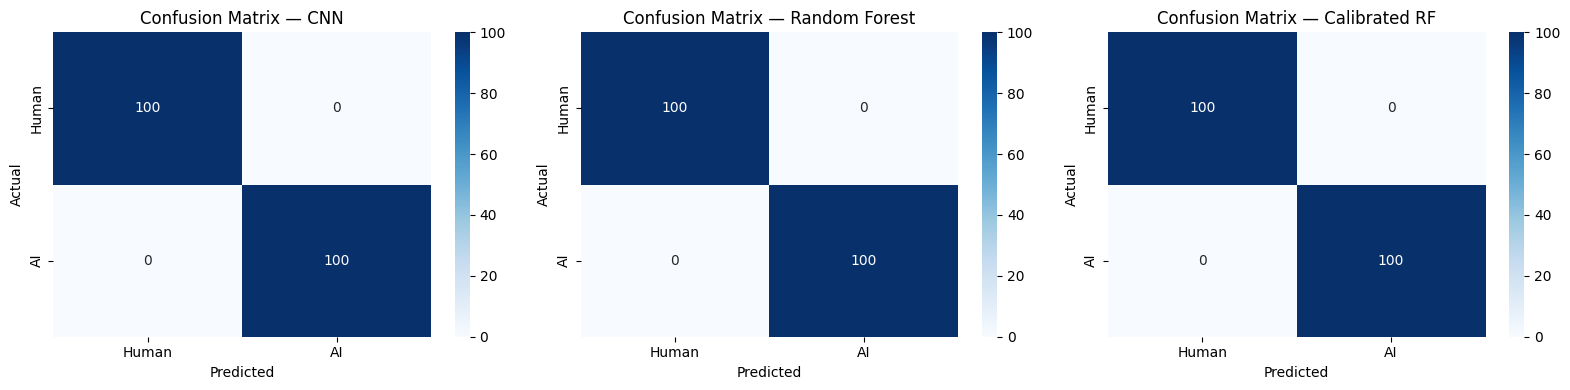

Saved to outputs/confusion_matrices.png


In [61]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, cm, name in zip(axes,
                        [cm_cnn, cm_rf, cm_cal],
                        ["CNN", "Random Forest", "Calibrated RF"]):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Human", "AI"],
                yticklabels=["Human", "AI"], ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix — {name}")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, "confusion_matrices.png"), dpi=150)
plt.show()
print("Saved to outputs/confusion_matrices.png")

### 8.2 ROC Curves (All Models on One Chart)

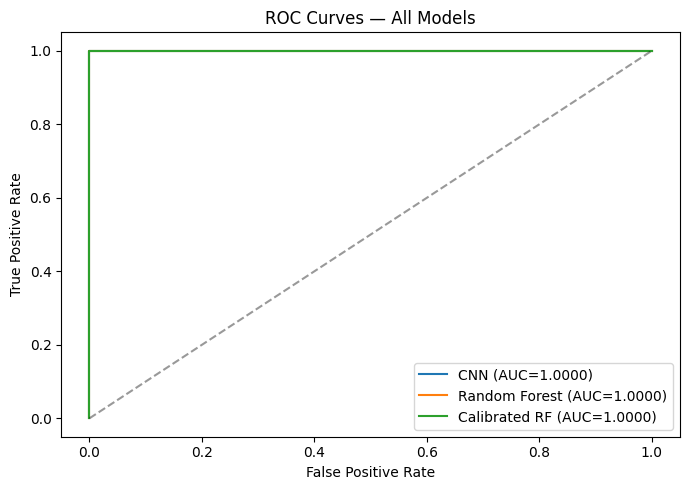

Saved to outputs/roc_curves.png


In [62]:
fig, ax = plt.subplots(figsize=(7, 5))

for prob, name in zip([prob_cnn, prob_rf, prob_cal],
                      ["CNN", "Random Forest", "Calibrated RF"]):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, "roc_curves.png"), dpi=150)
plt.show()
print("Saved to outputs/roc_curves.png")

### 8.3 CNN Training History

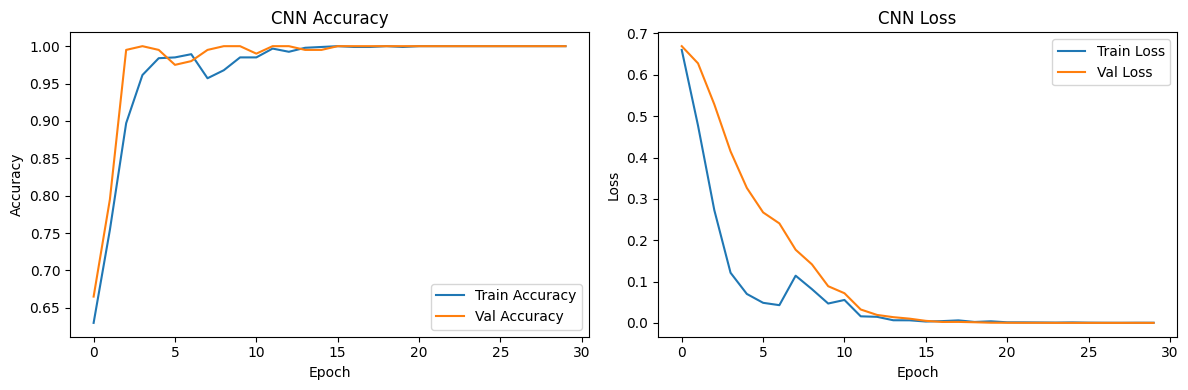

Saved to outputs/cnn_history.png


In [63]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(cnn_history.history["accuracy"],     label="Train Accuracy")
ax1.plot(cnn_history.history["val_accuracy"],  label="Val Accuracy")
ax1.set_title("CNN Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()

ax2.plot(cnn_history.history["loss"],     label="Train Loss")
ax2.plot(cnn_history.history["val_loss"],  label="Val Loss")
ax2.set_title("CNN Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, "cnn_history.png"), dpi=150)
plt.show()
print("Saved to outputs/cnn_history.png")

### 8.4 Calibration Reliability Diagram (RF vs Calibrated RF)

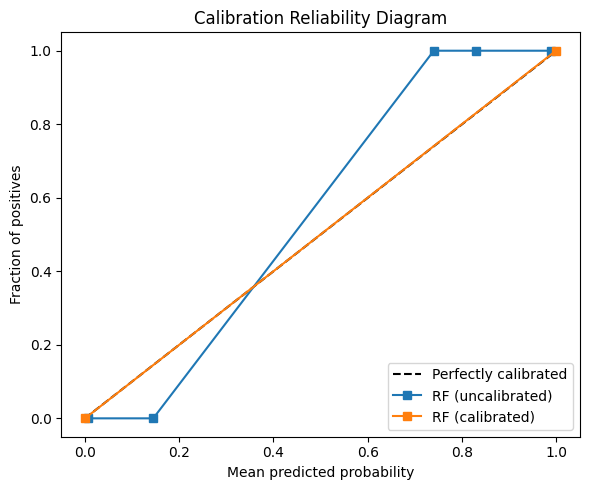

Saved to outputs/calibration_diagram.png


In [64]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")

for prob, label in [(prob_rf, "RF (uncalibrated)"),
                    (prob_cal, "RF (calibrated)")]:
    frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=10)
    ax.plot(mean_pred, frac_pos, "s-", label=label)

ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration Reliability Diagram")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, "calibration_diagram.png"), dpi=150)
plt.show()
print("Saved to outputs/calibration_diagram.png")

## 9. SHAP Explainability

In [65]:
import shap

print("Computing SHAP values (this may take a minute)...")
explainer = shap.TreeExplainer(rf_model)

# Use up to 200 test samples for speed (dataset is smaller)
n_shap = min(200, len(X_test))
X_shap = X_test[:n_shap]
shap_values = explainer.shap_values(X_shap)

# For binary classification, TreeExplainer returns [class_0, class_1]
if isinstance(shap_values, list):
    sv = shap_values[1]  # positive class (AI)
else:
    sv = shap_values

print(f"SHAP values shape: {sv.shape}")

Computing SHAP values (this may take a minute)...
SHAP values shape: (200, 32, 2)


### 9.1 SHAP Bar Plot — Top 20 Features

<Figure size 800x700 with 0 Axes>

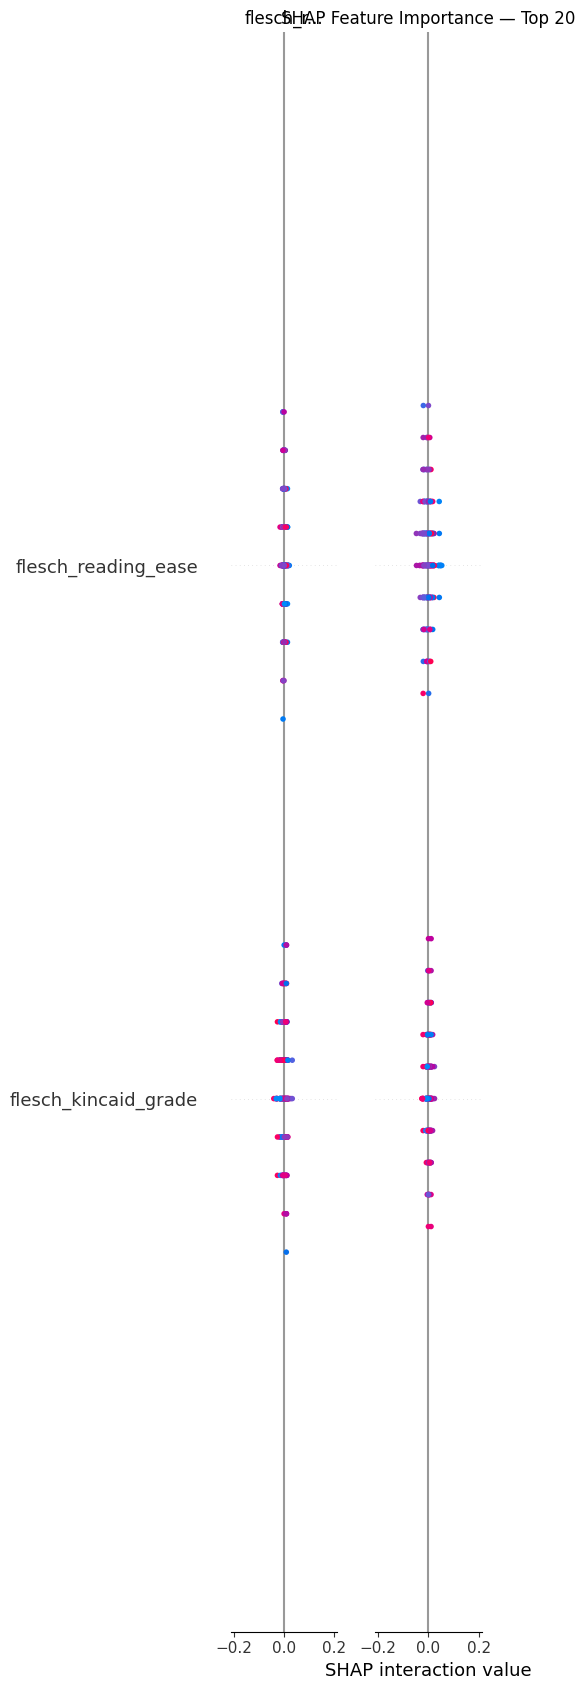

Saved to outputs/shap_bar.png


In [66]:
plt.figure(figsize=(8, 7))
shap.summary_plot(sv, X_shap, feature_names=FEATURE_NAMES,
                  plot_type="bar", max_display=20, show=False)
plt.title("SHAP Feature Importance — Top 20")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, "shap_bar.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved to outputs/shap_bar.png")

### 9.2 SHAP Beeswarm Plot

<Figure size 800x700 with 0 Axes>

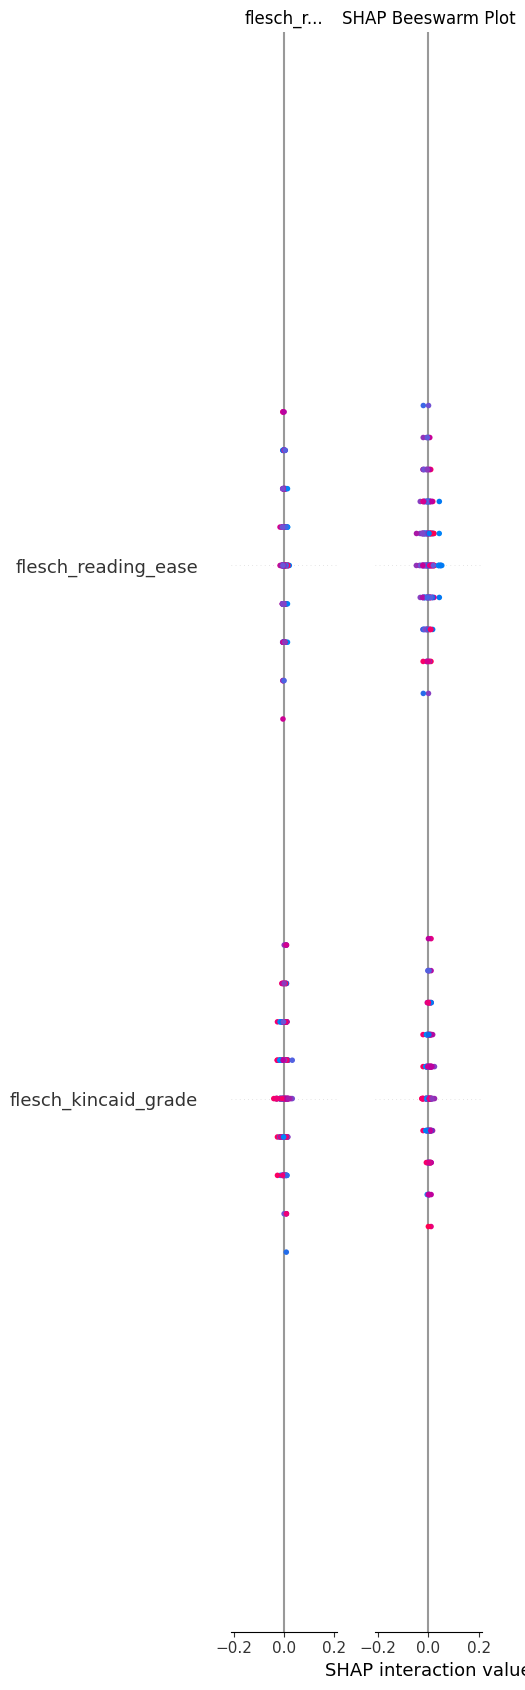

Saved to outputs/shap_beeswarm.png


In [67]:
plt.figure(figsize=(8, 7))
shap.summary_plot(sv, X_shap, feature_names=FEATURE_NAMES,
                  max_display=20, show=False)
plt.title("SHAP Beeswarm Plot")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, "shap_beeswarm.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved to outputs/shap_beeswarm.png")

### 9.3 SHAP Waterfall Plot — Single Prediction

Example index: 0
single_sv shape: (32, 2)
single_data shape: (32,)
Number of feature names: 32


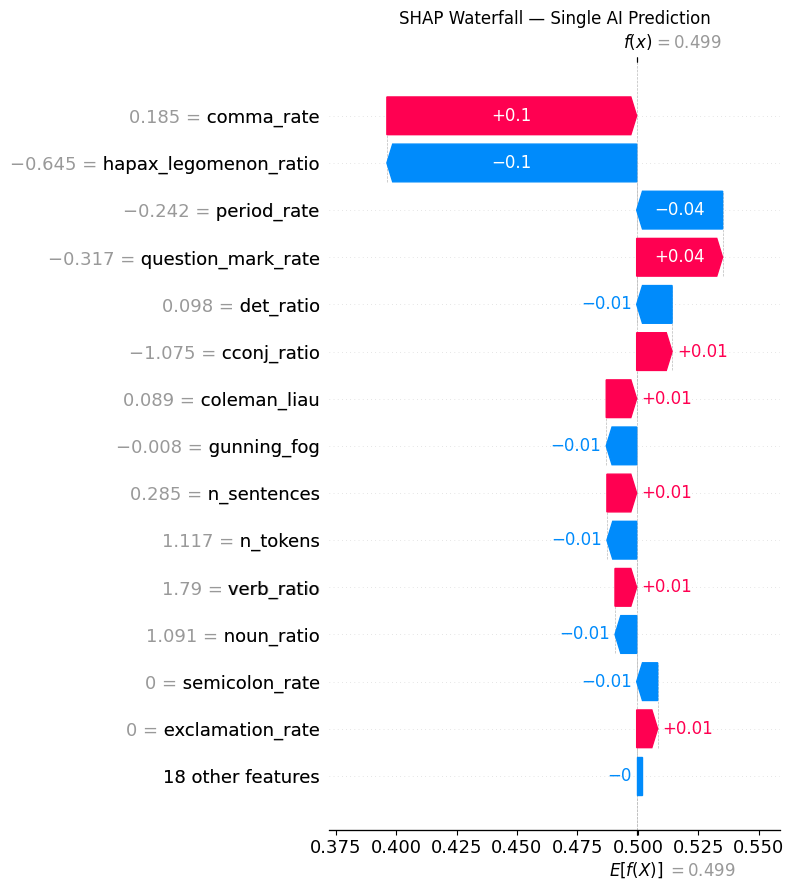

Saved to outputs/shap_waterfall.png


In [68]:
# Pick a sample classified as AI
example_idx = 0
for i in range(len(X_shap)):
    if rf_model.predict(X_shap[i:i+1])[0] == 1:
        example_idx = i
        break

print(f"Example index: {example_idx}")

# Use the SHAP values we already computed (sv) — grab one row
single_sv = sv[example_idx]
single_data = X_shap[example_idx]

# Debug shapes to make sure everything aligns
print(f"single_sv shape: {single_sv.shape}")
print(f"single_data shape: {single_data.shape}")
print(f"Number of feature names: {len(FEATURE_NAMES)}")

# Ensure all arrays are truly 1-D and same length
single_sv = np.array(single_sv).ravel()[:len(FEATURE_NAMES)]
single_data = np.array(single_data).ravel()[:len(FEATURE_NAMES)]

expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    ev = float(expected_value[1])
else:
    ev = float(expected_value)

# Build Explanation with matching lengths
explanation = shap.Explanation(
    values=single_sv,
    base_values=ev,
    data=single_data,
    feature_names=list(FEATURE_NAMES),
)

fig, ax = plt.subplots(figsize=(10, 7))
shap.plots.waterfall(explanation, max_display=15, show=False)
plt.title("SHAP Waterfall — Single AI Prediction")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, "shap_waterfall.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved to outputs/shap_waterfall.png")

### 9.4 Top 10 Features by SHAP Importance

In [69]:
mean_abs = np.mean(np.abs(sv), axis=0).ravel()[:len(FEATURE_NAMES)]
top_idx = np.argsort(mean_abs)[::-1][:10]

print("Top 10 features by mean |SHAP value|:")
print("-" * 45)
for rank, i in enumerate(top_idx, 1):
    i = int(i)
    print(f"  {rank:>2}. {FEATURE_NAMES[i]:<30s}  {mean_abs[i]:.4f}")

Top 10 features by mean |SHAP value|:
---------------------------------------------
   1. comma_rate                      0.0869
   2. hapax_legomenon_ratio           0.0869
   3. question_mark_rate              0.0337
   4. period_rate                     0.0337
   5. exclamation_rate                0.0183
   6. semicolon_rate                  0.0183
   7. cconj_ratio                     0.0175
   8. det_ratio                       0.0175
   9. pron_ratio                      0.0161
  10. adp_ratio                       0.0161


## 10. Summary

All models and plots have been saved:

**Models** (`models/`):
- `scaler.joblib` — StandardScaler
- `cnn_model.h5` — 1-D CNN
- `rf_model.joblib` — Random Forest
- `rf_calibrated.joblib` — Calibrated Random Forest

**Plots** (`outputs/`):
- `confusion_matrices.png`
- `roc_curves.png`
- `cnn_history.png`
- `calibration_diagram.png`
- `shap_bar.png`, `shap_beeswarm.png`, `shap_waterfall.png`
- `results.csv`

To run the web app: `python app.py` then open http://127.0.0.1:5000